# 03 - Avaliação de Modelos Baseline (TF-IDF)

## 1. Objetivo

Este notebook tem como objetivo avaliar o desempenho de modelos clássicos de aprendizado de máquina aplicados à detecção de fake news, utilizando representações vetoriais obtidas a partir do **TF-IDF (Term Frequency–Inverse Document Frequency)**.

A etapa corresponde à **Fase 3 do projeto**, responsável por definir um **baseline** que servirá de referência para comparações futuras com modelos baseados em *embeddings* (como Word2Vec, BERT e Sentence Transformers).

---

## 2. Importações e Configuração

In [1]:
# ==========================================
# 03_baseline_models.ipynb
# Avaliação dos modelos de baseline (TF-IDF + ML clássicos)
# ==========================================

# --- Configurações básicas ---
import sys
from pathlib import Path

# Adiciona a pasta raiz do projeto ao path
root_dir = Path.cwd().parent  # notebooks/ → detector-fakeNews/
sys.path.append(str(root_dir))

# --- Imports gerais ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
import joblib

# --- Imports locais ---
from src.models.utils_baseline import load_split


## 3. Carregar os Dados de Teste e o Vetorizador


In [2]:
# Caminhos padrão dos artefatos (ajustados para /notebooks)
test_path = Path("../data/processed/test.csv")
vectorizer_path = Path("../models/tfidf_vectorizer.pkl")

# Carregar dados de teste
test_df = load_split(str(test_path))
X_text = test_df["text"]
y_test = test_df["label"]

# Carregar o TF-IDF salvo na fase de treinamento
vectorizer = joblib.load(vectorizer_path)
X_test = vectorizer.transform(X_text)

print(f"✅ Total de exemplos no conjunto de teste: {len(y_test)}")
print(f"📊 Classes: {y_test.value_counts().to_dict()}")

✅ Total de exemplos no conjunto de teste: 1080
📊 Classes: {1: 540, 0: 540}


## 4. Avaliação dos Modelos Treinados


In [3]:
# Modelos disponíveis
model_names = {
    "linear_svm": "SVM Linear",
    "random_forest": "Random Forest"
}

results = []

for model_id, model_label in model_names.items():
    model_path = Path(f"../models/{model_id}.pkl")
    model = joblib.load(model_path)

    preds = model.predict(X_test)

    # Avaliação
    acc = round((preds == y_test).mean(), 4)
    f1 = round(f1_score(y_test, preds), 4)
    try:
        auc = round(roc_auc_score(y_test, preds), 4)
    except:
        auc = None

    results.append({
        "Modelo": model_label,
        "Acurácia": round(acc, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4) if auc else None
    })

results_df = pd.DataFrame(results)
results_df


,Modelo,Acurácia,F1-Score,AUC
0,SVM Linear,0.9602,0.9601,0.9602
1,Random Forest,0.9611,0.9614,0.9611


## 5. Matriz de Confusão para cada Modelo


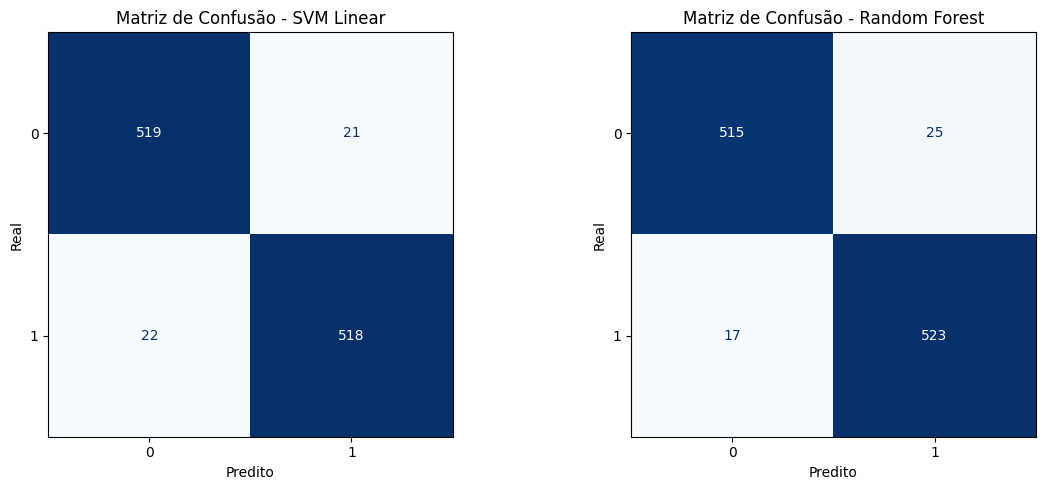

In [4]:
# Número total de modelos
n_models = len(model_names)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))

# Caso seja apenas 1 modelo, ajusta para lista
if n_models == 1:
    axes = [axes]

for ax, (model_id, model_label) in zip(axes, model_names.items()):
    model = joblib.load(f"../models/{model_id}.pkl")
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"Matriz de Confusão - {model_label}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

## 6. Comparação de Desempenho


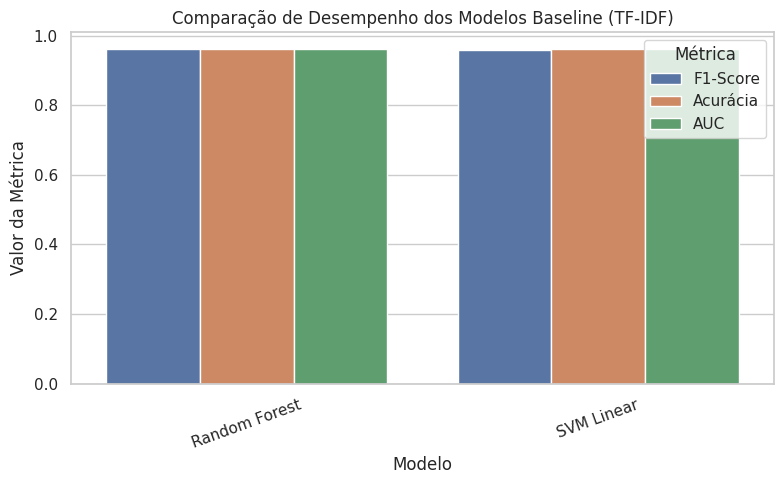

In [5]:
sns.set(style="whitegrid")
results_melted = results_df.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_melted.sort_values("Valor", ascending=False),
    x="Modelo", y="Valor", hue="Métrica"
)
plt.title("Comparação de Desempenho dos Modelos Baseline (TF-IDF)")
plt.xlabel("Modelo")
plt.ylabel("Valor da Métrica")
plt.xticks(rotation=20)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()


## 7. Salvando os Resultados Consolidados


In [6]:
# Caminho ajustado para salvar fora de /notebooks
output_path = Path("../models/results_baseline.csv")
results_df.to_csv(output_path, index=False)
print(f"✅ Resultados salvos em: {output_path}")


✅ Resultados salvos em: ../models/results_baseline.csv


## 8. Conclusões

Os resultados obtidos nesta fase indicam o desempenho dos modelos tradicionais de classificação de texto com representações baseadas em frequência (TF-IDF). Em geral:

- **Modelos lineares** (como Regressão Logística e SVM) tendem a apresentar **maior equilíbrio entre precisão e recall**, sendo mais eficazes em tarefas de classificação binária textual.
- **Naive Bayes** apresenta desempenho competitivo, especialmente em datasets textuais balanceados, mas pode perder precisão em casos de linguagem ambígua.
- **Random Forest**, apesar de robusto, nem sempre captura bem o contexto linguístico quando as features são puramente estatísticas.

Esses resultados fornecem um **baseline sólido** para a próxima fase do projeto, que explorará **representações semânticas profundas** através de *Word Embeddings* e *transformers*, permitindo capturar relações contextuais entre palavras e frases.

---

## 9. Próximos Passos

- Implementar representações com **Word2Vec, GloVe, BERT e Sentence Transformers**;
- Comparar as métricas obtidas com as do baseline TF-IDF;
- Avaliar impacto das representações vetoriais na detecção de desinformação;
- Incorporar técnicas de análise semântica para aperfeiçoar o entendimento textual.